**Esta análise busca identificar possíveis ações que possam compor a nossa carteira teórica com a finalidade de maximizar a precisão do nosso tracker. Para isso, serão utilizados os retornos simples, já que o objetivo deste estudo é identificar eventos extremos em dias pontuais. Serão considerados eventos extremos os dias em que o retorno de uma ação ultrapassou +15% ou foi inferior a -15%.**

Importando as bibliotecas necessárias

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Definindo uma váriavel para as ações que compõem o Ibovespa.

In [2]:
acoes = pd.read_csv('/content/drive/MyDrive/bootcamp FINOR/ibov_retornos_simples.csv', parse_dates=['Date'])
acoes = acoes.sort_values('Date').reset_index(drop=True)
print(acoes.head())

        Date  ABEV3.SA  AXIA3.SA  AXIA6.SA  AZZA3.SA  B3SA3.SA  BBAS3.SA  \
0 2018-01-03  0.002305 -0.012773 -0.016026  0.030195  0.017023  0.012754   
1 2018-01-04 -0.005520 -0.006469  0.014425  0.031552  0.006438  0.009595   
2 2018-01-05  0.003700 -0.009224 -0.025229 -0.033595  0.014499  0.000000   
3 2018-01-08 -0.001843  0.006572  0.002353 -0.012279  0.004624  0.002376   
4 2018-01-09 -0.002770 -0.039717 -0.042253 -0.006304 -0.014226 -0.009482   

   BBDC3.SA  BBDC4.SA  BBSE3.SA  ...  TAEE11.SA  TIMS3.SA  TOTS3.SA  UGPA3.SA  \
0  0.004254  0.004598  0.000697  ...   0.001398  0.000757  0.021227 -0.009874   
1  0.018209  0.016407  0.002089  ...  -0.015822 -0.004542 -0.006171  0.011678   
2  0.000304  0.005665  0.006602  ...   0.004728  0.008365  0.021569  0.002075   
3  0.000000 -0.000282  0.005868  ...  -0.004706 -0.013574 -0.000640  0.006989   
4 -0.007576 -0.009295 -0.003432  ...  -0.018440  0.001529  0.000320 -0.003856   

   USIM5.SA  VALE3.SA  VBBR3.SA  VIVT3.SA  WEGE3.SA  YDU

Convertendo os retornos simples para porcentagem, a fim de obter uma melhor compreensão.

In [3]:
acoes_pct = acoes.copy()
acoes_pct.iloc[:, 1:] = acoes_pct.iloc[:, 1:] * 100
print(acoes_pct.head())

        Date  ABEV3.SA  AXIA3.SA  AXIA6.SA  AZZA3.SA  B3SA3.SA  BBAS3.SA  \
0 2018-01-03  0.230527 -1.277280 -1.602552  3.019517  1.702335  1.275409   
1 2018-01-04 -0.551981 -0.646903  1.442521  3.155204  0.643755  0.959546   
2 2018-01-05  0.370032 -0.922411 -2.522916 -3.359544  1.449905  0.000000   
3 2018-01-08 -0.184343  0.657170  0.235280 -1.227943  0.462395  0.237616   
4 2018-01-09 -0.277004 -3.971708 -4.225347 -0.630361 -1.422597 -0.948164   

   BBDC3.SA  BBDC4.SA  BBSE3.SA  ...  TAEE11.SA  TIMS3.SA  TOTS3.SA  UGPA3.SA  \
0  0.425439  0.459751  0.069679  ...   0.139829  0.075738  2.122740 -0.987377   
1  1.820916  1.640694  0.208920  ...  -1.582168 -0.454219 -0.617109  1.167817   
2  0.030387  0.566458  0.660178  ...   0.472806  0.836534  2.156883  0.207543   
3  0.000000 -0.028175  0.586811  ...  -0.470581 -1.357442 -0.063979  0.698938   
4 -0.757603 -0.929550 -0.343176  ...  -1.843980  0.152871  0.032015 -0.385612   

   USIM5.SA  VALE3.SA  VBBR3.SA  VIVT3.SA  WEGE3.SA  YDU

Conforme documentado no Guia de dados & EDA, vamos verificar a existência de ativos que apresentem *retornos maiores do que 15%*, visto que esses retornos são raros e geralmente resultam de crises ou eventos importantes para a empresa.

In [5]:
acoes_extremas = []

for acao in acoes_pct.columns[1:]:
    extremos = acoes_pct[
        (acoes_pct[acao] > 15) |
        (acoes_pct[acao] < -15)
    ][['Date', acao]]

    if len(extremos) > 0:
        extremos = extremos.copy()
        extremos.columns = ['Date', 'Retorno']
        extremos['Acao'] = acao
        acoes_extremas.append(extremos)

resultado = pd.concat(acoes_extremas).sort_values('Date').reset_index(drop=True)
print(f'Total de retornos >15% : {len(resultado)}')
print(resultado.to_string(index=False))

Total de retornos >15%: 214
      Date    Retorno      Acao
2018-03-16  21.794869  SUZB3.SA
2018-04-09  18.810299  MBRF3.SA
2018-04-10  17.726660  MBRF3.SA
2018-05-11 -15.209137  COGN3.SA
2018-06-06  26.055965  ISAE4.SA
2018-06-15  21.400771  BRKM5.SA
2018-07-04  17.985061  AXIA3.SA
2018-07-04  16.612390  AXIA6.SA
2018-10-08  17.333357  AXIA3.SA
2018-10-08  15.558050  CSMG3.SA
2018-10-08  17.803453  CMIG4.SA
2018-10-08  16.718408  VBBR3.SA
2018-10-08  18.310474  AXIA6.SA
2018-12-07  44.887130  ISAE4.SA
2019-01-03  27.624527  AXIA3.SA
2019-01-18 -16.978433  MRVE3.SA
2019-01-21  21.143860  MRVE3.SA
2019-01-28 -16.657129  BRAP4.SA
2019-01-28 -24.559232  VALE3.SA
2019-06-04 -17.111640  BRKM5.SA
2019-08-23 -17.261916 BPAC11.SA
2019-08-26 -17.949635 BPAC11.SA
2019-08-27  17.974574 BPAC11.SA
2020-03-02  16.618068  HYPE3.SA
2020-03-09 -29.697769  PETR4.SA
2020-03-09 -25.292518  CSNA3.SA
2020-03-09 -15.280354  BRAP4.SA
2020-03-09 -15.198362  VALE3.SA
2020-03-09 -16.137233  USIM5.SA
2020-03-09 -

In [6]:
resultado['Ano'] = resultado['Date'].dt.year
print(resultado.groupby('Ano')['Retorno'].count())

Ano
2018     14
2019      9
2020    157
2021      7
2022     12
2023     11
2024      4
Name: Retorno, dtype: int64


Dentre as 214 ocorrências de eventos extremos encontrados, *157 aconteceram no ano de 2020* -- provavelmentem em decorrência da pandemia de Covid-19. Sob essa perspectiva, conclui-se que não foi um movimento isolado, mas um movimento generalizado no mercado.

---
A fim de buscar por ações que tenham influencia no comportamento do índice, cabe analisar quantas vezes cada ação teve retornos maiores que 15%.


In [7]:
contagem = resultado.groupby('Acao')['Retorno'].count().sort_values(ascending=False)
print(contagem)

Acao
BRKM5.SA     12
PRIO3.SA     12
MGLU3.SA     11
HAPV3.SA      9
COGN3.SA      8
MBRF3.SA      8
BPAC11.SA     8
AXIA3.SA      7
PETR3.SA      7
UGPA3.SA      7
USIM5.SA      6
CSNA3.SA      6
AXIA6.SA      6
YDUQ3.SA      6
POMO4.SA      5
PETR4.SA      5
RENT3.SA      5
CYRE3.SA      5
MRVE3.SA      5
BEEF3.SA      4
CSMG3.SA      4
VALE3.SA      4
BBDC4.SA      4
SBSP3.SA      4
RAIL3.SA      4
BBAS3.SA      4
GOAU4.SA      3
GGBR4.SA      3
MULT3.SA      3
SUZB3.SA      3
LREN3.SA      3
BRAP4.SA      3
AZZA3.SA      3
ENEV3.SA      2
TOTS3.SA      2
HYPE3.SA      2
CMIG4.SA      2
B3SA3.SA      2
BBDC3.SA      2
FLRY3.SA      2
DIRR3.SA      2
VBBR3.SA      2
WEGE3.SA      2
ISAE4.SA      2
ABEV3.SA      1
CSAN3.SA      1
CPLE3.SA      1
ITUB4.SA      1
KLBN11.SA     1
Name: Retorno, dtype: int64


Conferindo se os dias em que as ações listadas tiveram retornos extremos coincidem com os períodos de turbulência no índice Ibovespa

In [8]:
datas_outliers_indice = [
    '2020-01-27', '2020-02-26', '2020-03-05', '2020-03-06',
    '2020-03-09', '2020-03-10', '2020-03-11', '2020-03-12',
    '2020-03-13', '2020-03-16', '2020-03-17', '2020-03-18',
    '2020-03-23', '2020-03-24', '2020-03-25', '2020-03-26',
    '2020-03-27', '2020-04-03', '2020-04-06', '2020-04-24',
    '2020-04-27', '2020-04-28', '2020-04-30', '2020-05-18',
    '2020-05-25', '2020-06-08', '2020-10-28'
]

datas_outliers_indice = pd.to_datetime(datas_outliers_indice)

acoes_nos_outliers = resultado[resultado['Date'].isin(datas_outliers_indice)]

print(f'Total de eventos extremos coincidentes: {len(acoes_nos_outliers)}')
print('\nQuantidade por ação:')
print(acoes_nos_outliers.groupby('Acao')['Retorno'].count().sort_values(ascending=False))

Total de eventos extremos coincidentes: 142

Quantidade por ação:
Acao
PRIO3.SA     9
MBRF3.SA     6
MGLU3.SA     6
PETR3.SA     6
BRKM5.SA     5
BPAC11.SA    5
COGN3.SA     5
CYRE3.SA     5
POMO4.SA     5
UGPA3.SA     5
CSNA3.SA     4
BBAS3.SA     4
AXIA3.SA     4
AXIA6.SA     4
PETR4.SA     4
USIM5.SA     4
RENT3.SA     4
RAIL3.SA     3
MRVE3.SA     3
GOAU4.SA     3
GGBR4.SA     3
YDUQ3.SA     3
VALE3.SA     3
SBSP3.SA     3
CSMG3.SA     2
BEEF3.SA     2
BBDC4.SA     2
AZZA3.SA     2
B3SA3.SA     2
BRAP4.SA     2
SUZB3.SA     2
TOTS3.SA     2
WEGE3.SA     2
MULT3.SA     2
ENEV3.SA     2
DIRR3.SA     2
LREN3.SA     2
HAPV3.SA     2
CMIG4.SA     1
BBDC3.SA     1
ABEV3.SA     1
FLRY3.SA     1
HYPE3.SA     1
KLBN11.SA    1
CSAN3.SA     1
VBBR3.SA     1
Name: Retorno, dtype: int64


Ações que mais se destacam:

* PRIO3 — 9 coincidências, a mais presente nos dias de crise do índice

* MGLU3, PETR3 e MBRF3 — 6 coincidências cada

* PETR3 e PETR4 juntas somam 10 coincidências — e como Petrobras tem grande peso no Ibovespa, isso é muito relevante compreender o desempenho do tracker.

Vamos criar um gráfico com as top 5 ações que tiveram mais semelhança com o períodos de crise do índice.

In [9]:
indice_ibov = pd.read_csv('/content/drive/MyDrive/bootcamp FINOR/ibov_indice_retornos.csv', parse_dates=['Date'])
indice_ibov = indice_ibov.sort_values('Date').reset_index(drop=True)

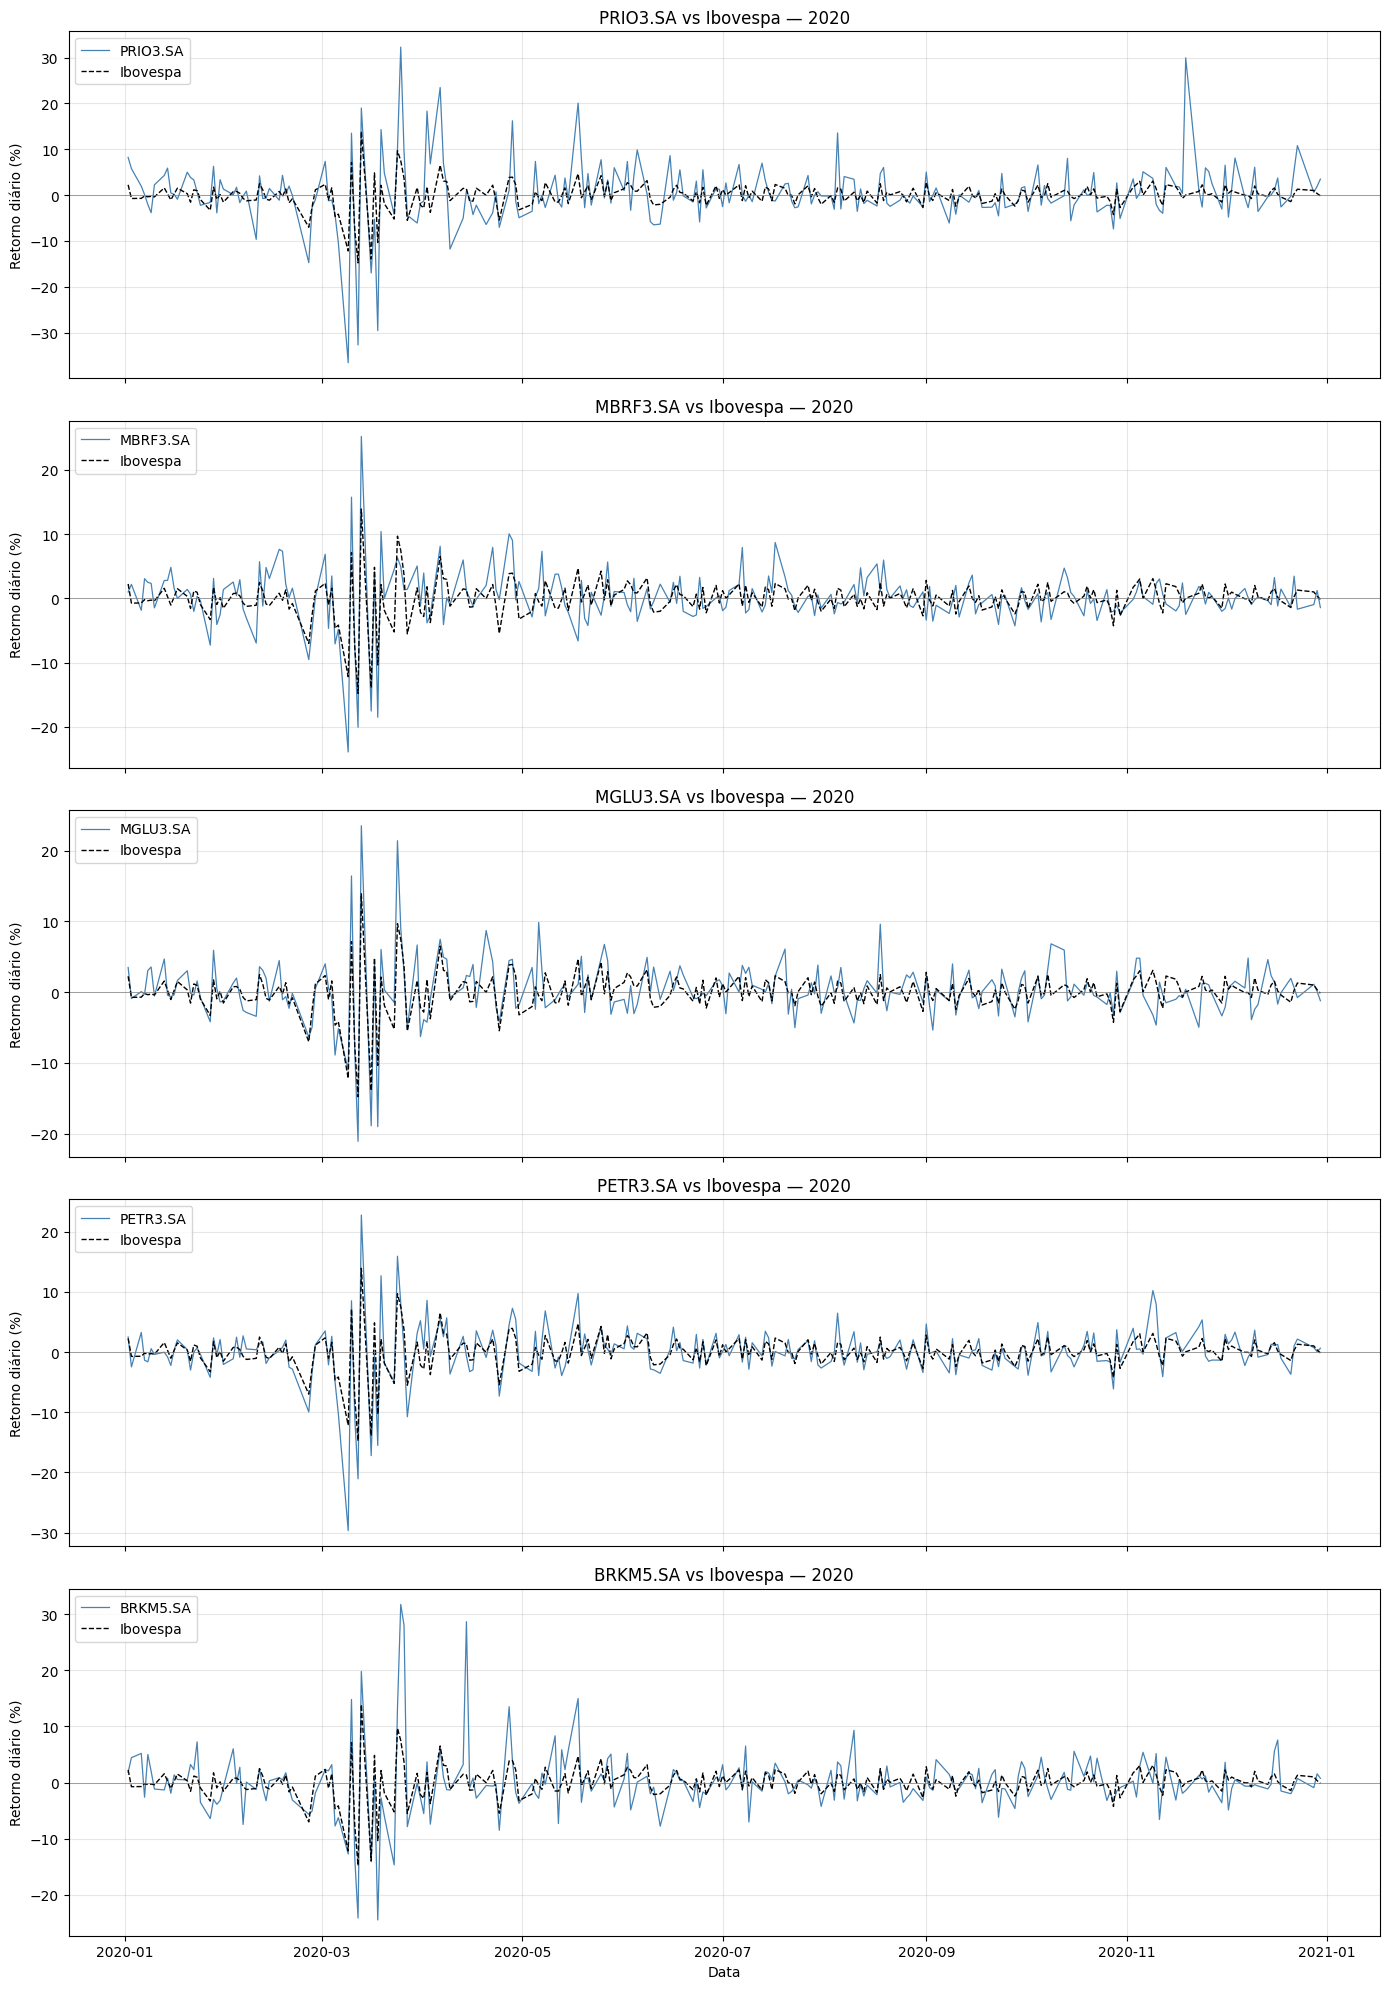

In [12]:

acoes_2020 = acoes_pct[(acoes_pct['Date'].dt.year == 2020)].set_index('Date')
indice_2020 = indice_ibov[(indice_ibov['Date'].dt.year == 2020)].set_index('Date')

top5 = ['PRIO3.SA', 'MBRF3.SA', 'MGLU3.SA', 'PETR3.SA', 'BRKM5.SA']

fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)

for i, acao in enumerate(top5):
    axes[i].plot(acoes_2020.index, acoes_2020[acao], linewidth=0.9, label=acao, color='steelblue')
    axes[i].plot(indice_2020.index, indice_2020['Variação_Diária_%'], color='black', linewidth=1, linestyle='--', label='Ibovespa')
    axes[i].axhline(y=0, color='gray', linewidth=0.5)
    axes[i].set_title(f'{acao} vs Ibovespa — 2020')
    axes[i].set_ylabel('Retorno diário (%)')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Data')
plt.tight_layout()
plt.show()

Das cinco ações analisadas, **PETR3** é a que mais se comporta como o índice. As demais amplificam os movimentos do índice em diferentes graus, sendo **PRIO3** e **BRKM5** as mais problemáticas para o tracker por serem estruturalmente mais voláteis.

Conclui-se que o ativo **PETR3** é um candidato natural a estar presente na carteira teórica do Index Tracking. Isso porque, por possuir grande peso no índice (~4,19%) e apresentar comportamento semelhante ao Ibovespa mesmo em momentos de crise, sua presença na carteira contribui para a mitigação do tracking error nos períodos de maior turbulência do mercado.